Sales Forecasting



Preliminary analysis:

Import the datasets into the Python environment

Examine the dataset's shape and structure, and look out for any outlier

Merge the datasets into a single dataset that includes the date, item id, price, item count, item names, kcal values, store id, and store name

In [ ]:
# for EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# for prediction models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping
# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
# plt.style.use("fivethirtyeight")
pal = sns.color_palette()
pal_list = list(pal)
# for image study
import torch
import datetime as dt
import os
import tqdm

In [ ]:
items = pd.read_csv('/content/sample_data/items.csv')
restaurants = pd.read_csv('/content/sample_data/resturants.csv')
sales = pd.read_csv('/content/sample_data/sales.csv')

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   item_count  109600 non-null  int64  
 3   price       109600 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ MB


In [ ]:
sales.date = pd.to_datetime(sales.date, format="%d-%m-%Y")

In [ ]:
items

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07
...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
97,98,2,Original Sweet Milky Soft Drink,579,5.00
98,99,4,Frozen Tomato Soft Drink,423,5.32


In [ ]:
restaurants

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [ ]:
sales

,date,item_id,item_count,price
0,2019-01-01,3,2,58.44
1,2019-01-01,4,22,581.24
2,2019-01-01,12,7,34.09
3,2019-01-01,13,12,50.16
4,2019-01-01,16,136,436.56
...,...,...,...,...
109595,2021-12-31,96,0,0.00
109596,2021-12-31,97,0,0.00
109597,2021-12-31,98,0,0.00
109598,2021-12-31,99,0,0.00


In [ ]:
sales.head()

,date,item_id,item_count,price
0,2019-01-01,3,2,58.44
1,2019-01-01,4,22,581.24
2,2019-01-01,12,7,34.09
3,2019-01-01,13,12,50.16
4,2019-01-01,16,136,436.56


In [ ]:
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


Merge data to create a single data with date item id, price, item count, item names, kcal values, store id and store name.

In [ ]:
merged_data = pd.merge(sales, items, left_on = "item_id", right_on = "id", how = "left")

In [ ]:
merged_data

,date,item_id,item_count,price,id,store_id,name,kcal,cost
0,2019-01-01,3,2,58.44,3,1,Sweet Fruity Cake,931,29.22
1,2019-01-01,4,22,581.24,4,1,Amazing Steak Dinner with Rolls,763,26.42
2,2019-01-01,12,7,34.09,12,1,Fantastic Sweet Cola,478,4.87
3,2019-01-01,13,12,50.16,13,1,Sweet Frozen Soft Drink,490,4.18
4,2019-01-01,16,136,436.56,16,1,Frozen Milky Smoothy,284,3.21
...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,0,0.00,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
109596,2021-12-31,97,0,0.00,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
109597,2021-12-31,98,0,0.00,98,2,Original Sweet Milky Soft Drink,579,5.00
109598,2021-12-31,99,0,0.00,99,4,Frozen Tomato Soft Drink,423,5.32


In [ ]:
data = pd.merge(merged_data, restaurants, left_on = 'store_id', right_on = 'id')

In [ ]:
data

,date,item_id,item_count,price,id_x,store_id,name_x,kcal,cost,id_y,name_y
0,2019-01-01,3,2,58.44,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,22,581.24,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,7,34.09,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,12,50.16,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,136,436.56,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner
...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,0,0.00,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93,5,Corner Cafe
109596,2021-12-31,97,0,0.00,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,4,Fou Cher
109597,2021-12-31,98,0,0.00,98,2,Original Sweet Milky Soft Drink,579,5.00,2,Beachfront Bar
109598,2021-12-31,99,0,0.00,99,4,Frozen Tomato Soft Drink,423,5.32,4,Fou Cher


In [ ]:
data.shape

(109600, 11)

In [ ]:
(data.item_id == data.id_x).all()

np.True_

In [ ]:
(data.store_id == data.id_y).all()

np.True_

In [ ]:
data.rename(columns = {"name_x" : "item_name", "name_y": "restaurant_name"}, inplace = True)

In [ ]:
data.drop(columns = ['id_x', 'id_y', 'cost'], inplace = True)

In [ ]:
data.shape

(109600, 8)

In [ ]:
data

,date,item_id,item_count,price,store_id,item_name,kcal,restaurant_name
0,2019-01-01,3,2,58.44,1,Sweet Fruity Cake,931,Bob's Diner
1,2019-01-01,4,22,581.24,1,Amazing Steak Dinner with Rolls,763,Bob's Diner
2,2019-01-01,12,7,34.09,1,Fantastic Sweet Cola,478,Bob's Diner
3,2019-01-01,13,12,50.16,1,Sweet Frozen Soft Drink,490,Bob's Diner
4,2019-01-01,16,136,436.56,1,Frozen Milky Smoothy,284,Bob's Diner
...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,0,0.00,5,Blue Ribbon Fish with Bread Lunch,708,Corner Cafe
109596,2021-12-31,97,0,0.00,4,Original Fruity Cod with Bread and Vegetables ...,744,Fou Cher
109597,2021-12-31,98,0,0.00,2,Original Sweet Milky Soft Drink,579,Beachfront Bar
109598,2021-12-31,99,0,0.00,4,Frozen Tomato Soft Drink,423,Fou Cher


EDA

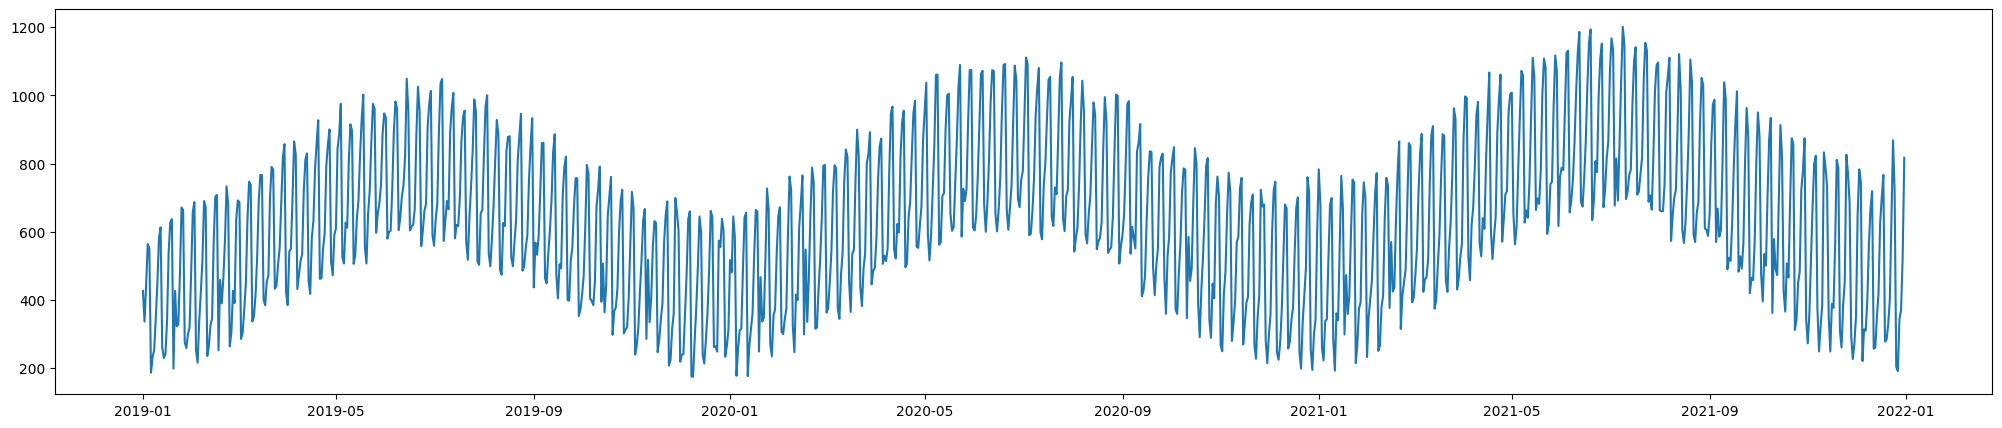

In [ ]:
grpd = sales.groupby(['date'])[['item_count']].sum()
plt.figure(figsize = (25,5))
plt.plot(grpd)
plt.show()

In [ ]:
data['weekday'] = data.date.dt.day_name()

In [ ]:
import calendar

day_names = list(calendar.day_name)

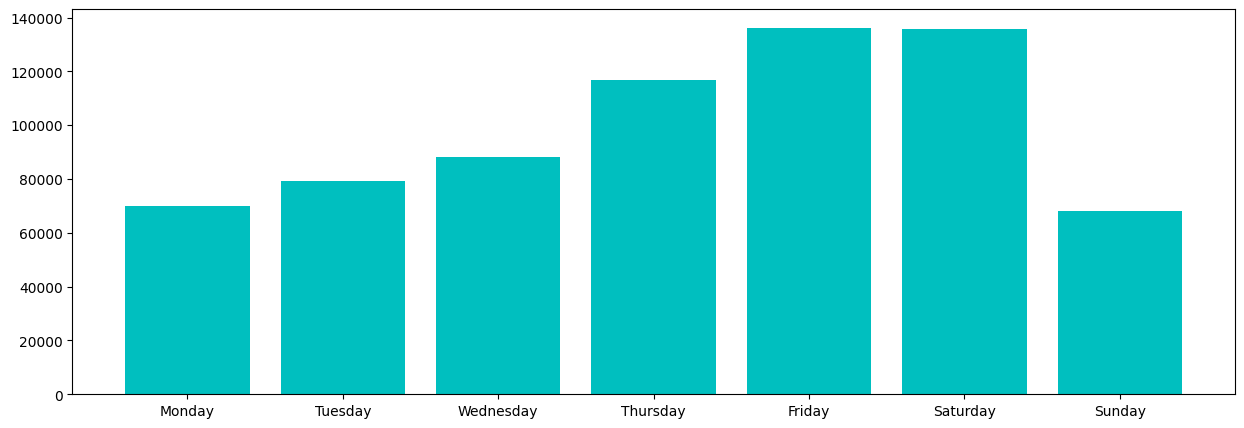

In [ ]:
grpd = data.groupby(['weekday'])[['item_count']].sum()

grpd = grpd.loc[day_names].squeeze()

plt.figure(figsize = (15,5))

plt.bar(height = grpd.values, x = grpd.index, color ='c')

plt.show()

Look for any noticeable trends in the sales data for different months of the year.

In [ ]:
data['month_name'] = data.date.dt.month_name()

In [ ]:
months = list(calendar.month_name)[1:]

/tmp/ipython-input-1329588800.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')


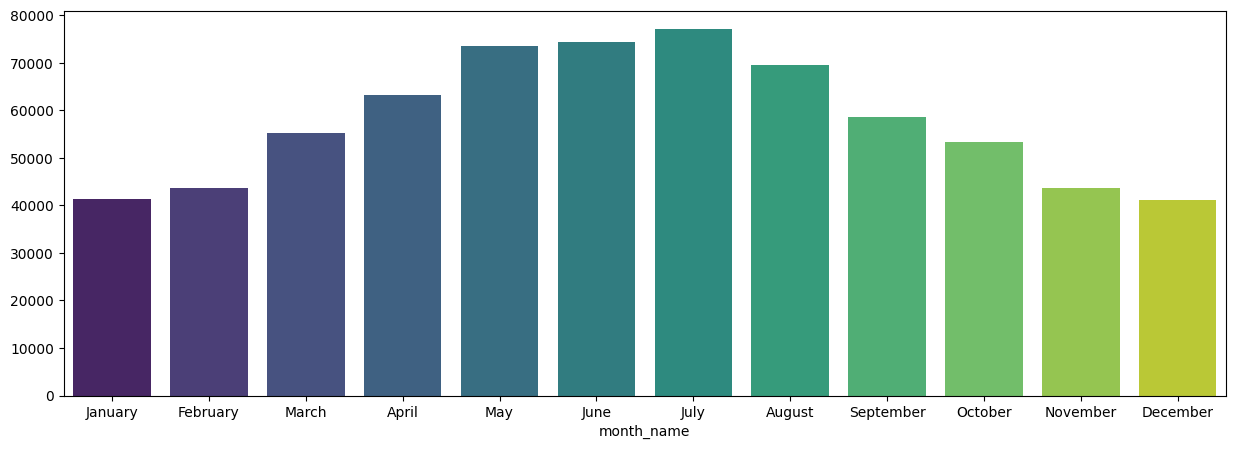

In [ ]:
grpd = data.groupby(['month_name'])[['item_count']].sum()

grpd = grpd.loc[months].squeeze()

plt.figure(figsize = (15,5))

sns.barplot(y= grpd.values, x = grpd.index,palette='viridis')

plt.show()

In [ ]:
data['quarter'] = data.date.dt.quarter

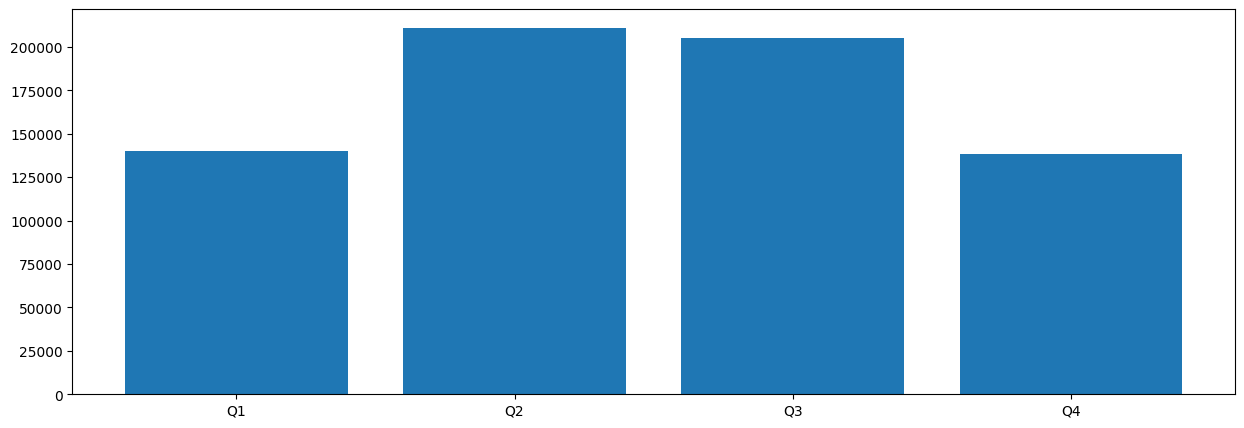

In [ ]:
grpd = data.groupby(['quarter'])[['item_count']].sum().squeeze()

plt.figure(figsize = (15,5))

plt.bar(height = grpd.values, x = grpd.index)

plt.xticks(range(1,5),["Q"+str(i) for i in range(1,5)])

plt.show()

In [ ]:
data['year'] = data.date.dt.year

In [ ]:
data['quart-year'] = "Q" + data.quarter.astype(str) + "-" + data.year.astype(str)

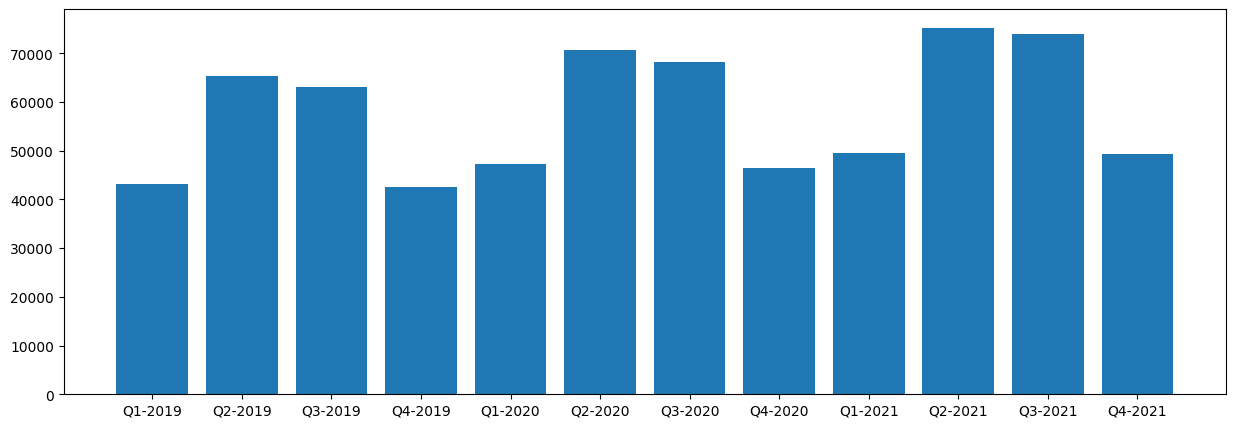

In [ ]:
order = ['Q{}-{}'.format(j,i) for i in range(2019, 2022) for j in range(1,5)]
grpd = data.groupby(["quart-year"])[['item_count']].sum()
grpd = grpd.loc[order].squeeze()
plt.figure(figsize = (15,5))
plt.bar(height = grpd.values, x = grpd.index)
plt.show()

Compare the performances of different restaurants.Which restaurant had the most sales? Also study the sales for each restaurant across different years months and days.

In [ ]:
data.groupby('store_id')[['item_count']].sum()

,item_count
store_id,
1,687527
2,1305
3,1736
4,1106
5,1310
6,1803


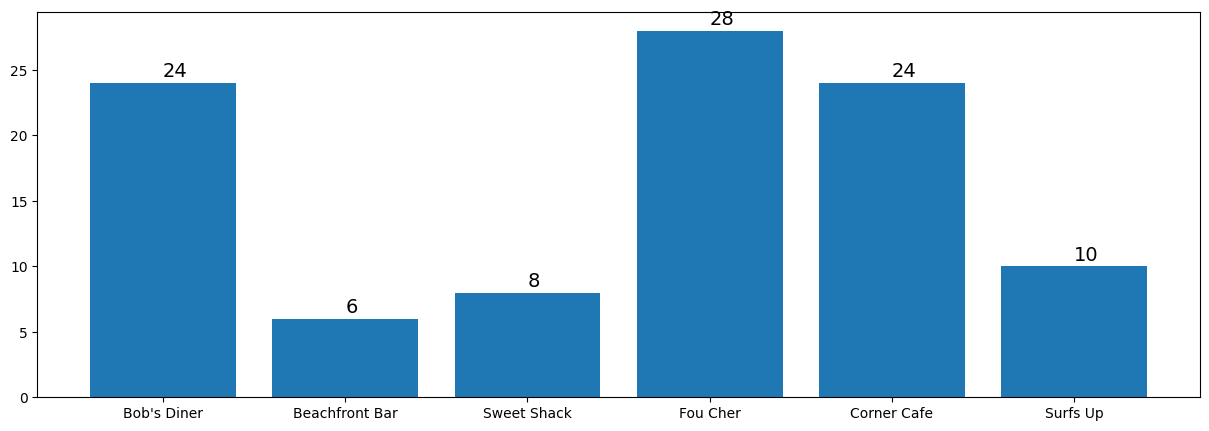

In [ ]:
items_served = items.groupby(['store_id']).agg({'id' : "nunique"}).squeeze()
plt.figure(figsize = (15,5))
plt.bar(items_served.index, items_served.values)
plt.xticks(range(1,7), restaurants.name)
for i in range(1,7):
  plt.annotate(items_served[i], xy = (i, items_served[i]+0.45), size = 14)
plt.show()

In [ ]:
# plt.style.use("fivethirtyeight")

pal = sns.color_palette()

pal_list = list(pal)

In [ ]:
plot_data = data.pivot_table(index = 'date', columns = 'store_id',values = 'item_count', aggfunc = 'sum')

In [ ]:
plot_data

store_id,1,2,3,4,5,6
date,,,,,,
2019-01-01,421,1,0,1,2,2
2019-01-02,330,1,1,2,1,2
2019-01-03,438,1,2,3,0,1
2019-01-04,559,2,2,1,0,0
2019-01-05,545,1,2,2,2,0
...,...,...,...,...,...,...
2021-12-27,184,2,2,2,0,2
2021-12-28,340,1,0,1,0,2
2021-12-29,366,1,2,0,1,1


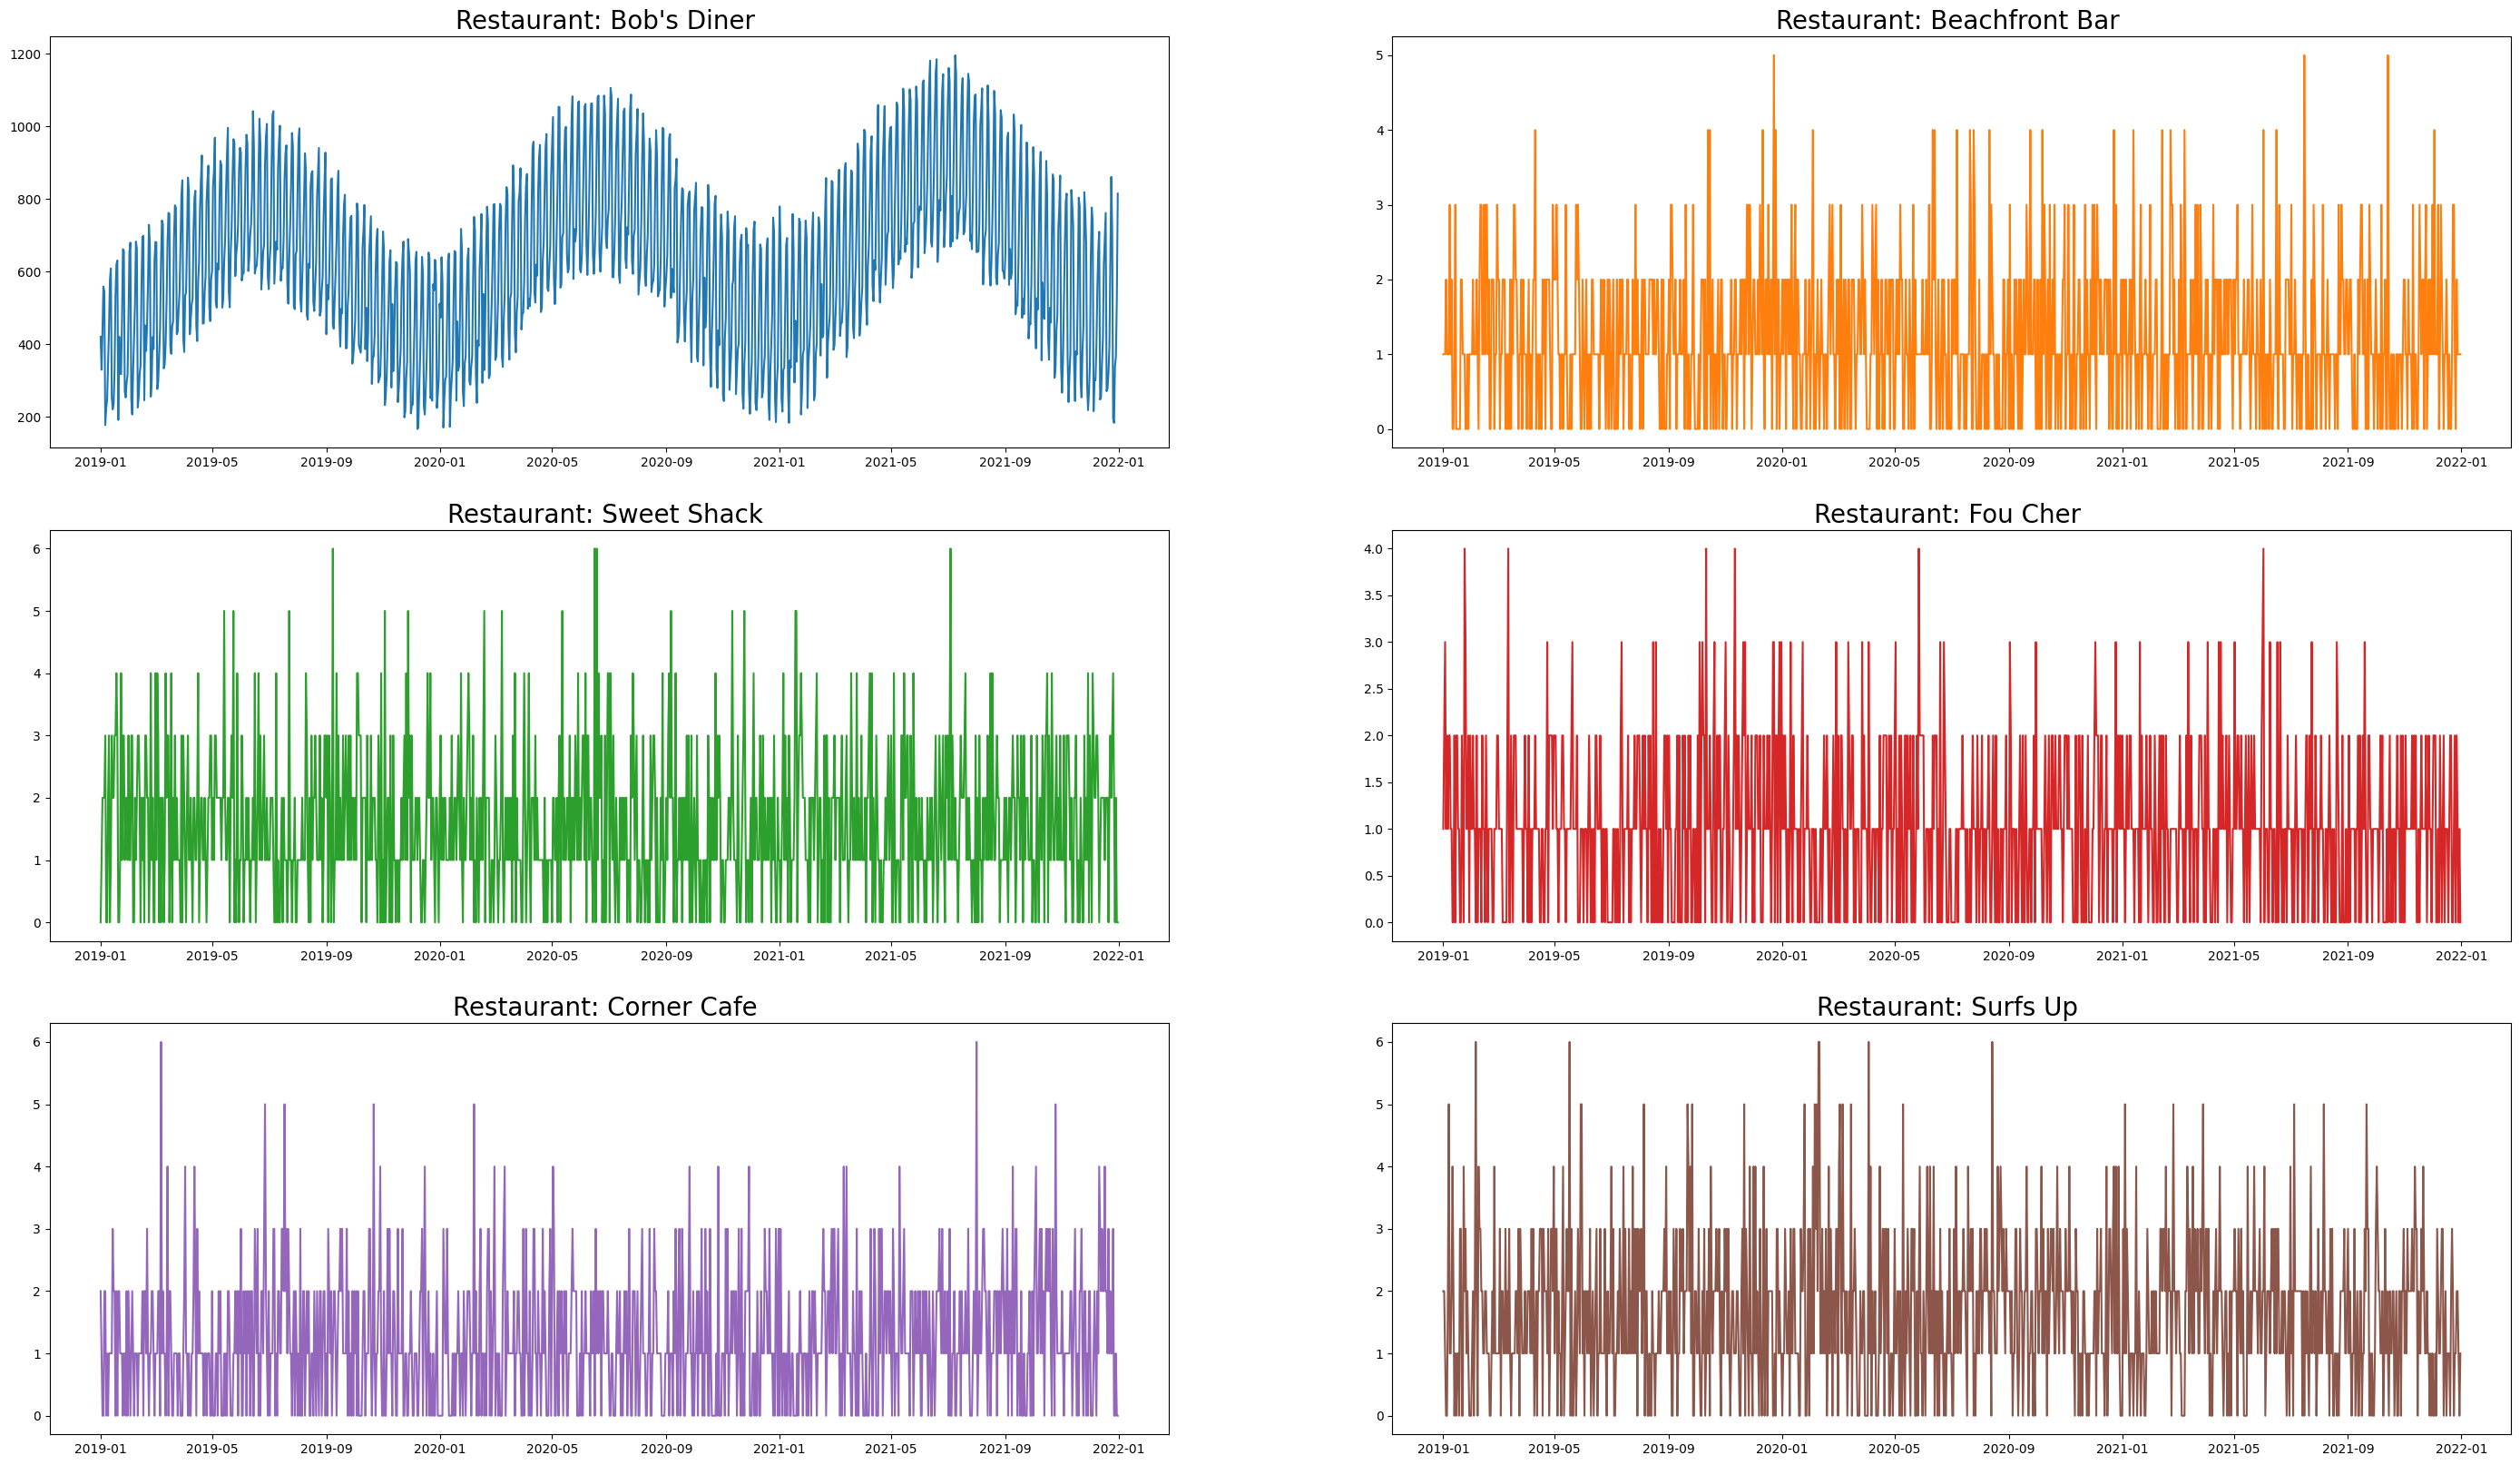

In [ ]:
f,ax = plt.subplots(3,2,figsize =(35,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].plot(plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

year wise sales for each store

In [ ]:
plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')

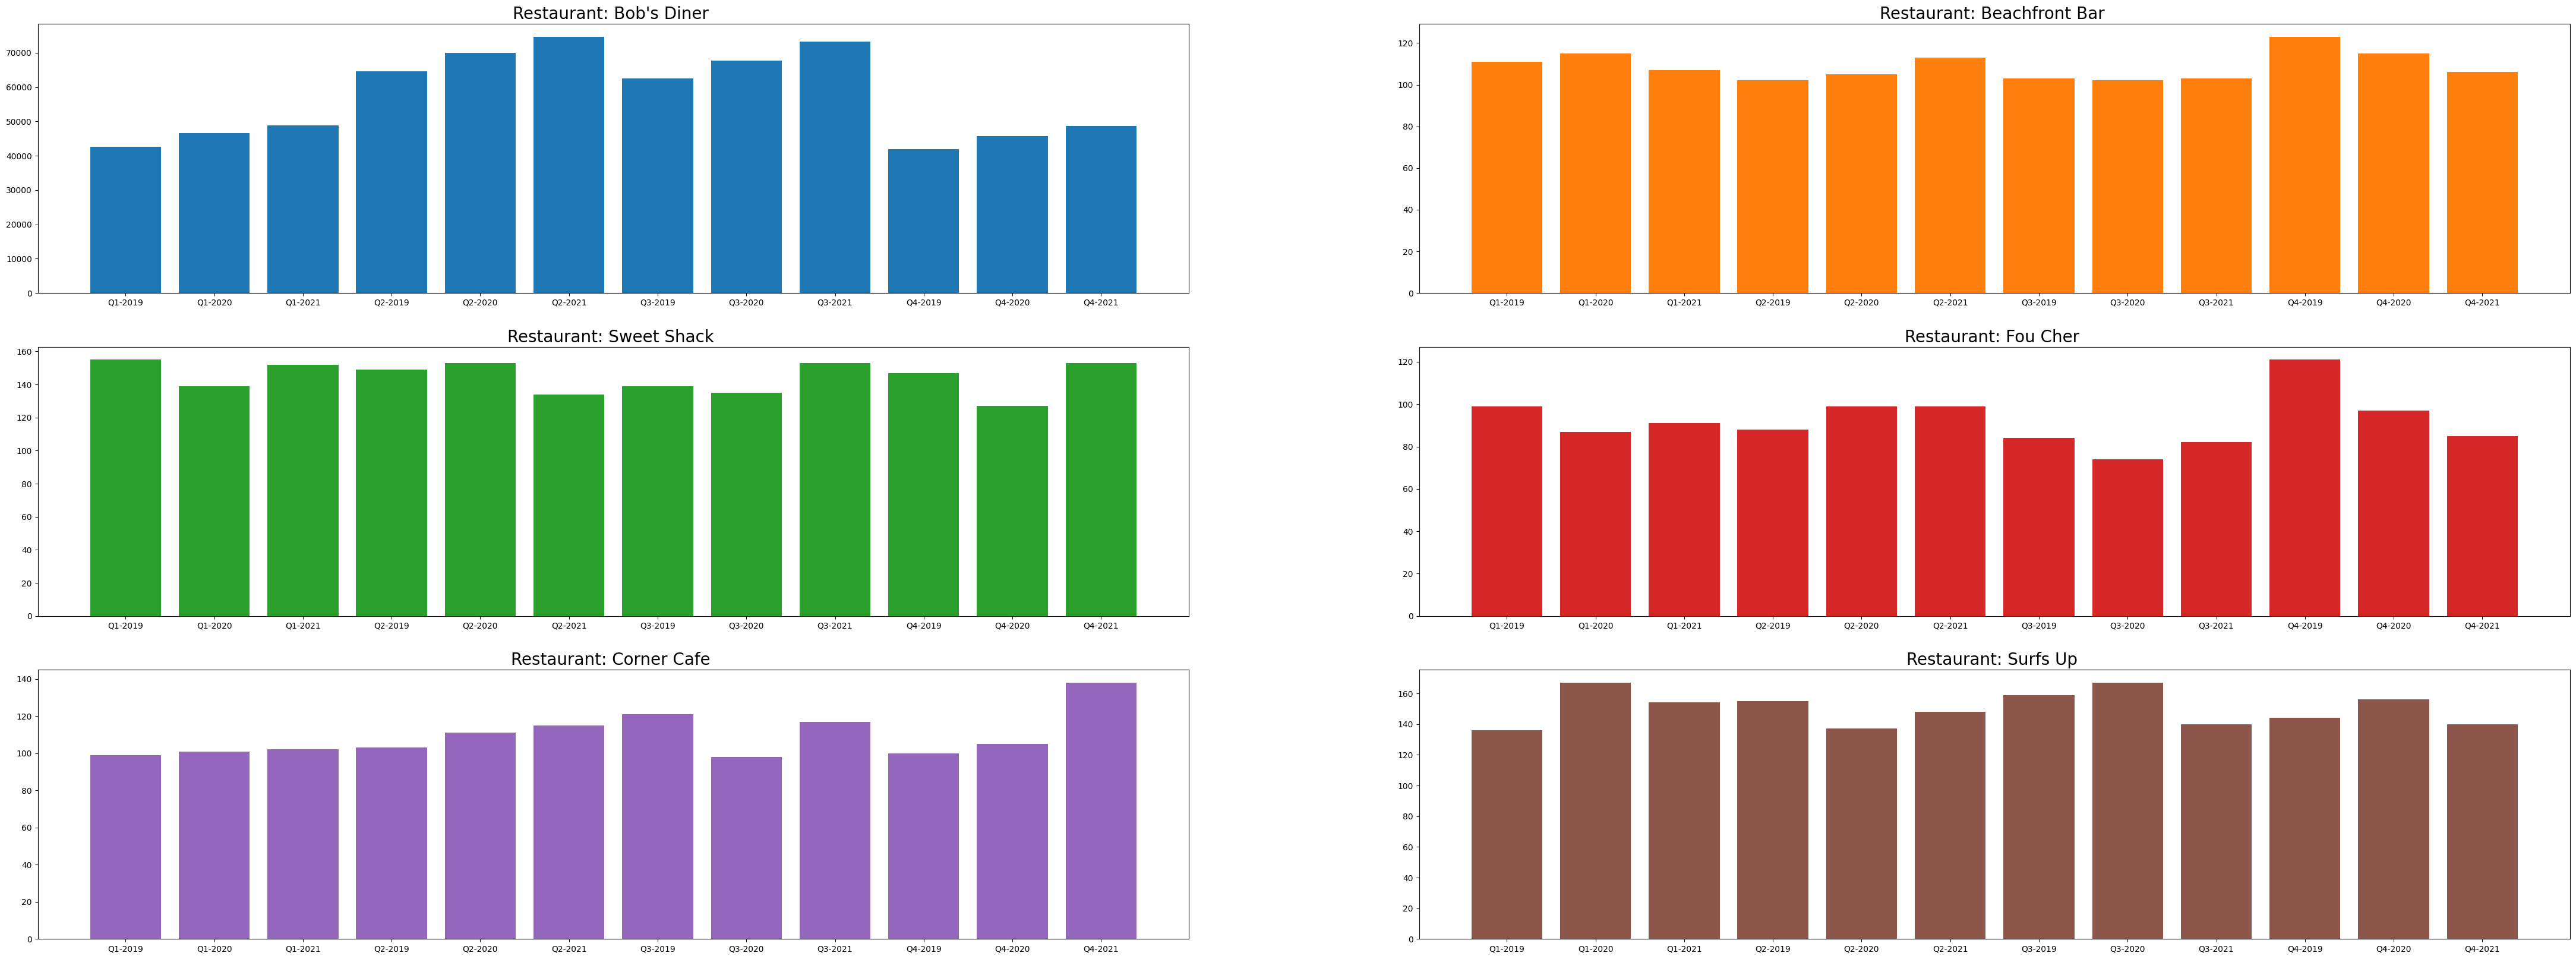

In [ ]:
plot_data = data.pivot_table(index = 'quart-year', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
f,ax = plt.subplots(3,2,figsize =(55,20) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('Restaurant: {} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

Month wise sales

/tmp/ipython-input-2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipython-input-2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipython-input-2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipython-input-2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
/tmp/ipython-input-2619853384.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of tic

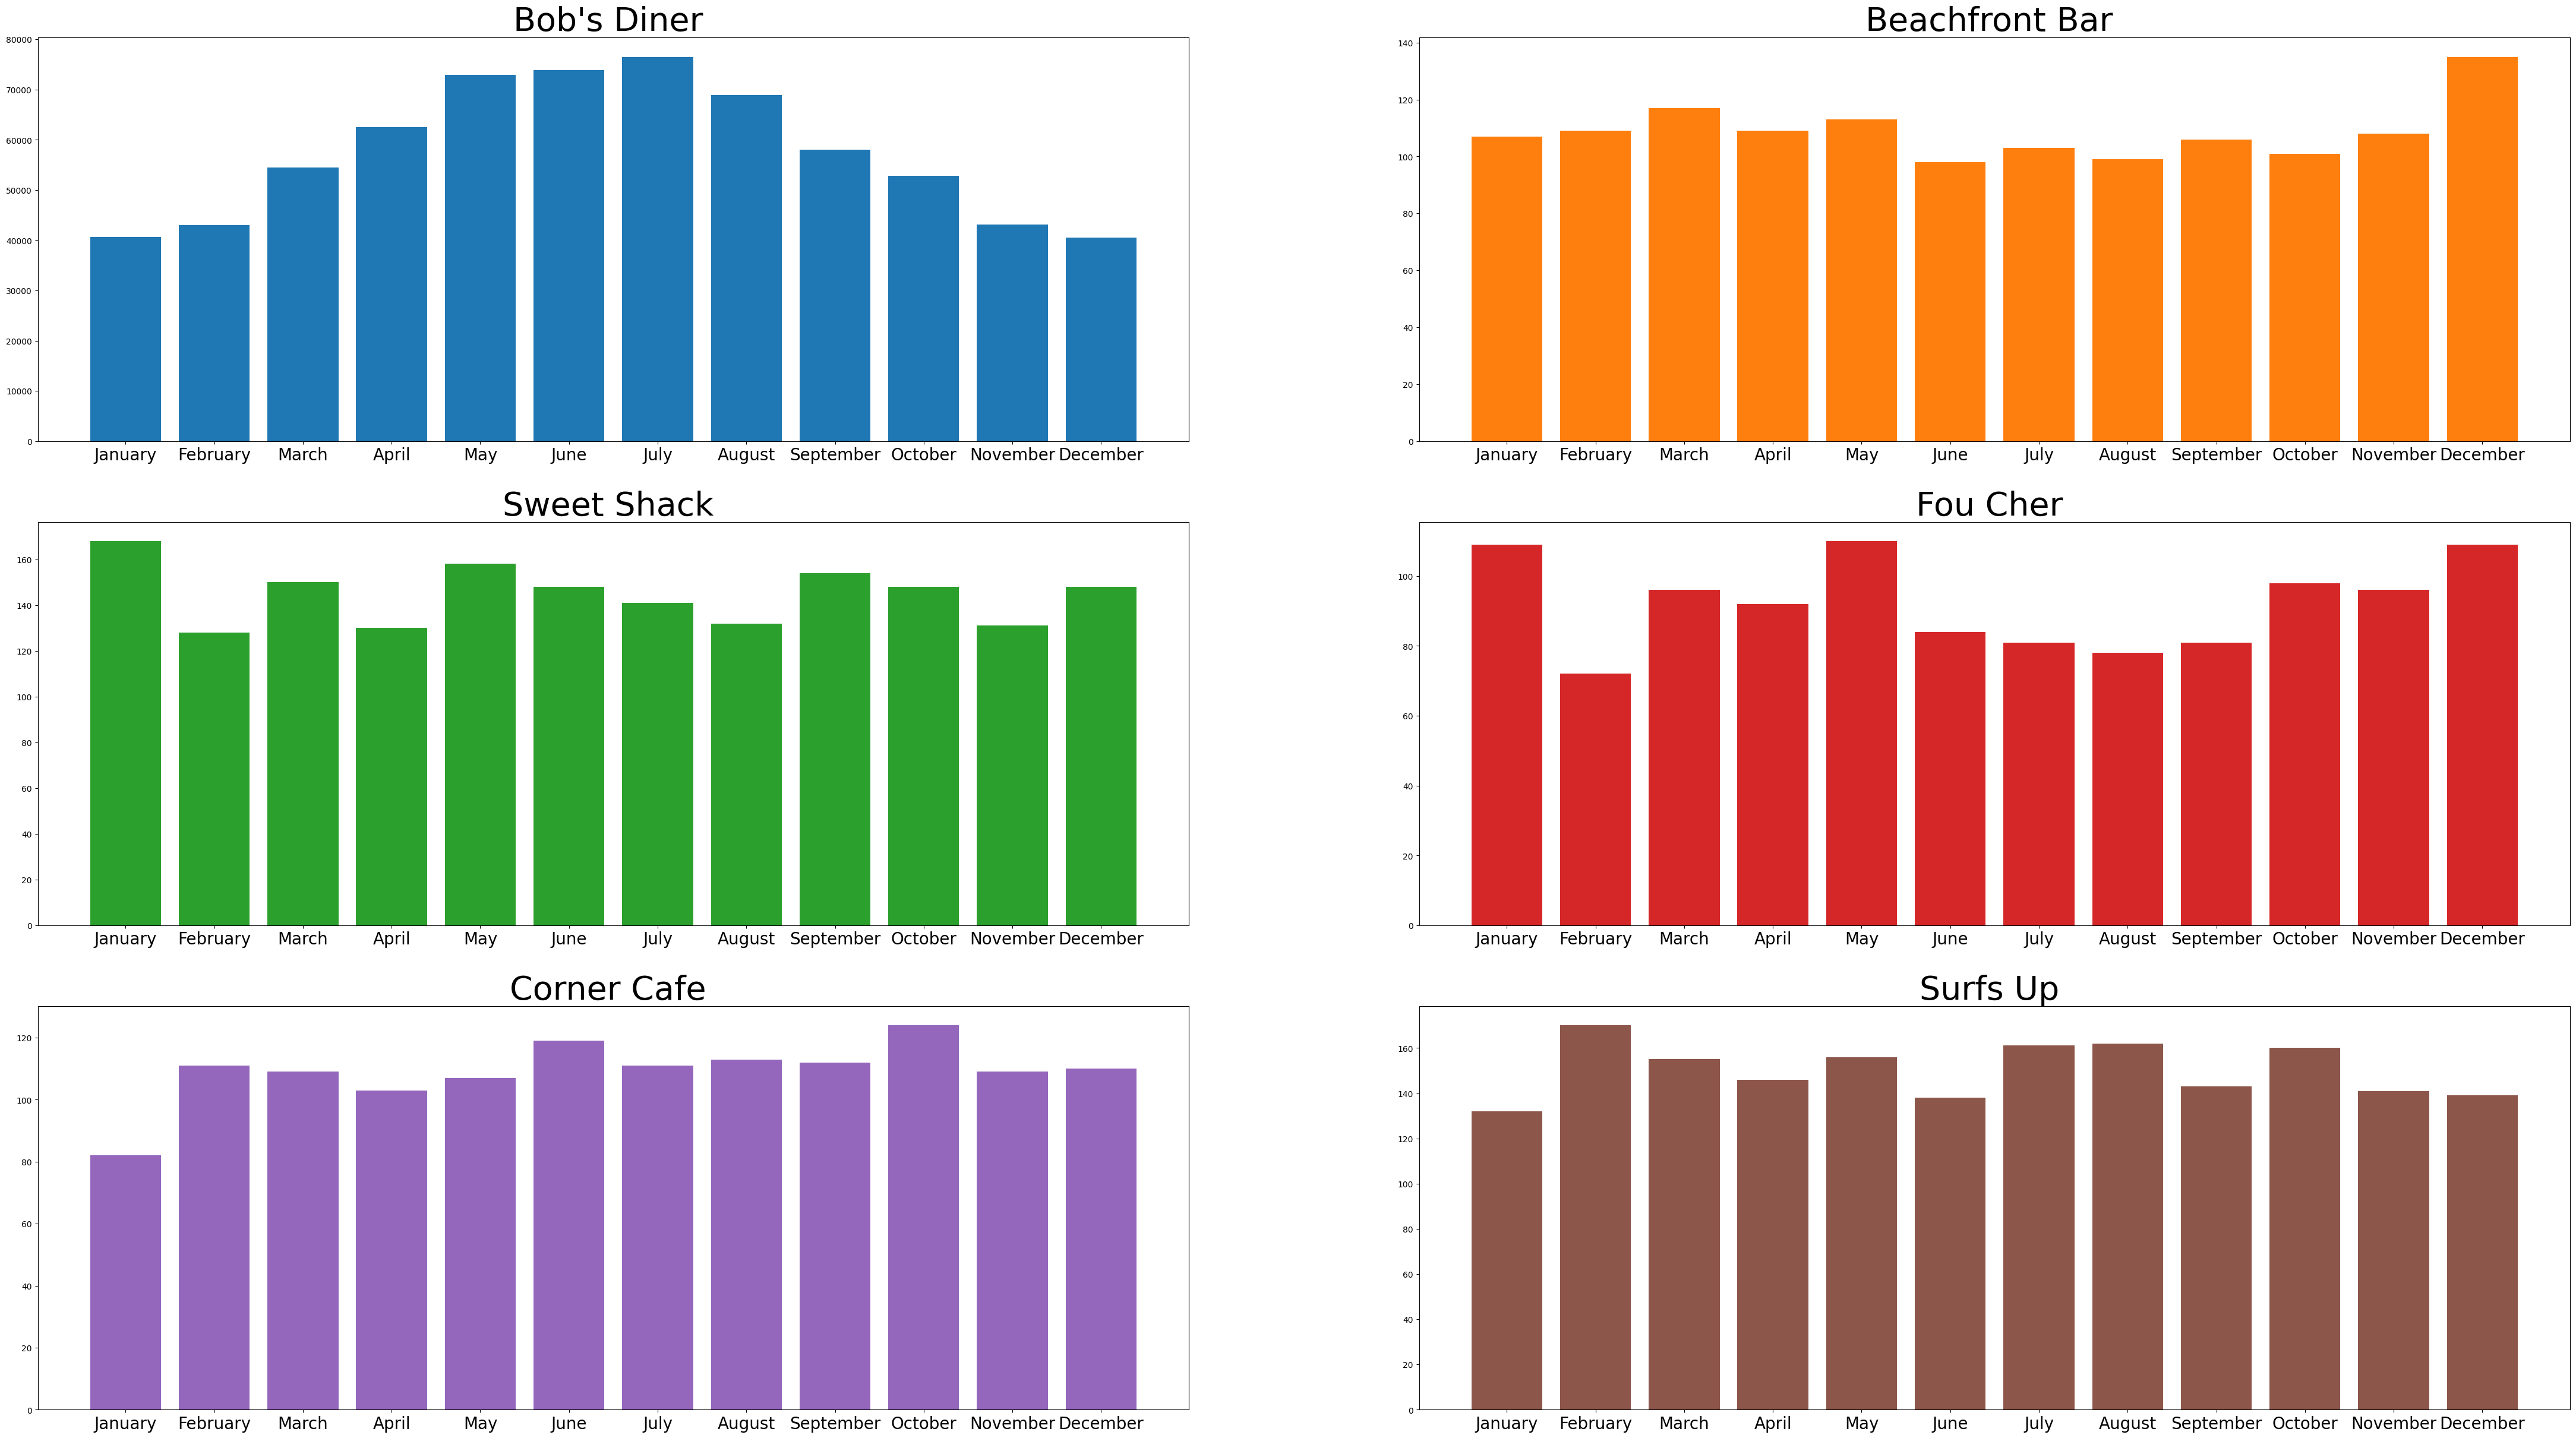

In [ ]:
plot_data = data.pivot_table(index = 'month_name', columns = 'store_id',values = 'item_count', aggfunc = 'sum')
plot_data = plot_data.loc[months]
f,ax = plt.subplots(3,2,figsize =(55,30) )
r,c = 0,0
for i in range(1,7):
  ax[r,c].bar(x = plot_data.index,height = plot_data.loc[:, i], color = pal_list[i-1])
  ax[r,c].set_title('{} '.format(restaurants.loc[restaurants.id == i, 'name'].values[0]), size = 40)
  ax[r,c].set_xticklabels(labels = months, fontsize = 20)
  c += 1
  if c == 2:
    c = 0
    r +=1

dentify the most popular items overall and the stores where they are being sold. Also find out the most popular item at the store.

In [ ]:
plot_data = data.groupby('item_id')[['item_count']].sum().sort_values('item_count',ascending = False).reset_index()[:5]

In [ ]:
final_plot_data = pd.merge(plot_data, items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]

In [ ]:
final_plot_data

,item_id,item_count,name,kcal,cost,store_id
0,19,236337,Strawberry Smoothy,145,2.89,1
1,16,102990,Frozen Milky Smoothy,284,3.21,1
2,76,61043,Amazing pork lunch,679,17.93,1
3,38,52772,Mutton Dinner,542,10.80,1
4,9,43874,Orange Juice,135,3.91,1


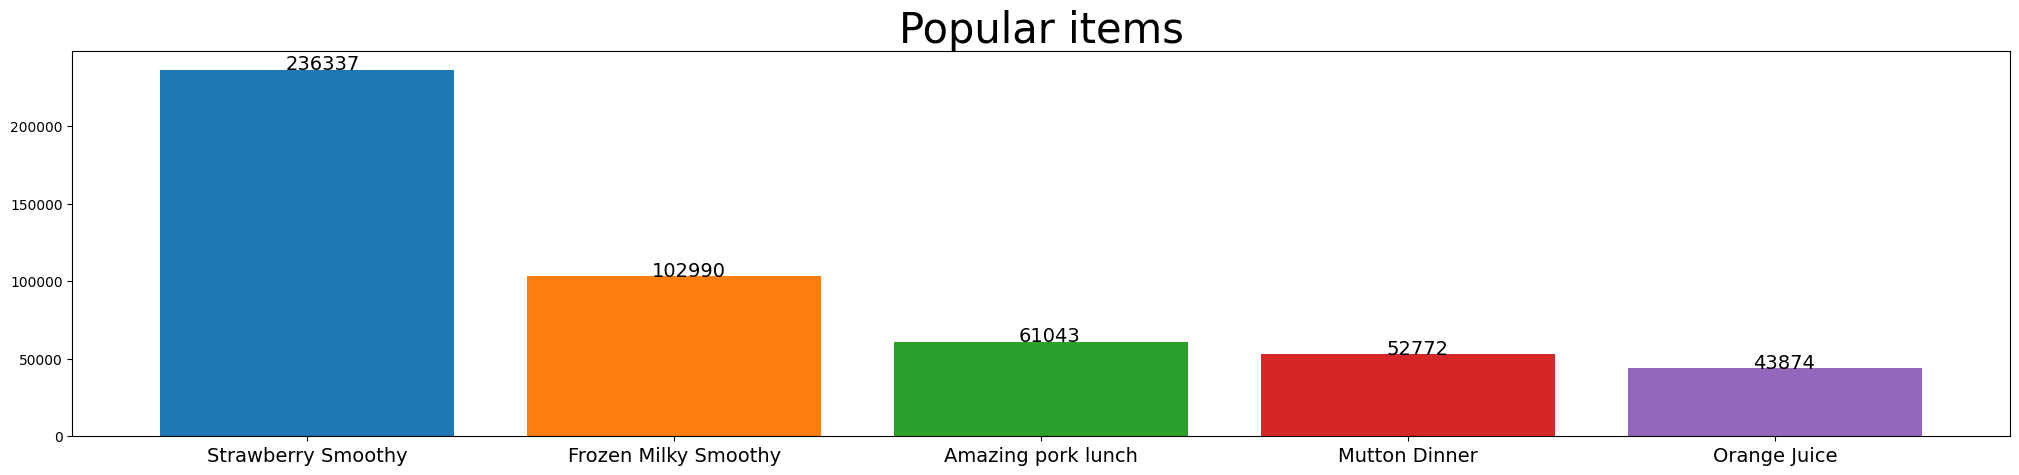

In [ ]:
final_plot_data = pd.merge(plot_data, items, left_on = 'item_id', right_on = 'id', how = 'left')[['item_id', 'item_count', 'name', 'kcal', 'cost', 'store_id']]
plt.figure(figsize = (25,5))
plt.bar(final_plot_data.name, final_plot_data.item_count, color = pal_list)
plt.title('Popular items', size= 30)
for k in range(5):
  val = final_plot_data.loc[k,'item_count']
  plt.annotate('{:0.0f}'.format(val), xy = (k-0.06, val), size = 14)
plt.xticks(size = 14)
plt.show()

Popular items restaurant wise

In [ ]:
count_data = data.pivot_table(index = 'item_id', columns = 'store_id',values = 'item_count', aggfunc = 'sum', fill_value = 0 )
item_ids = count_data.index[count_data.values.argmax(axis = 0)]

In [ ]:
pop_items = items.loc[items.id.isin(item_ids), ['store_id', 'id', 'name', 'kcal', 'cost']]
pop_data = pd.merge(pop_items, restaurants, how = 'left', left_on = 'store_id', right_on = 'id', suffixes = ('_item', '_restaurant'))
pop_data['count'] = count_data.loc[item_ids,].sum(axis = 0).reset_index().iloc[:,1]
pop_data = pop_data[['name_restaurant', 'name_item', 'kcal', 'cost', 'count']]
pop_data

,name_restaurant,name_item,kcal,cost,count
0,Bob's Diner,Strawberry Smoothy,145,2.89,236337
1,Beachfront Bar,Fantastic Milky Smoothy,318,2.91,1147
2,Sweet Shack,Awesome Smoothy,78,1.39,1692
3,Corner Cafe,Frozen Milky Smoothy,211,3.98,298
4,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98,273
5,Surfs Up,Awesome Soft Drink,248,3.06,997


Determine if the store with the highest sales volume is also making the most money per day.

In [ ]:
data.groupby('store_id')[['item_count']].sum().reset_index()

,store_id,item_count
0,1,687527
1,2,1305
2,3,1736
3,4,1106
4,5,1310
5,6,1803


In [ ]:
data.pivot_table(index = 'store_id', columns = 'year', values = 'item_count', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,211799,230191,245537
2,439,437,429
3,590,554,592
4,392,357,357
5,423,415,472
6,594,627,582


In [ ]:
data['sales_amnt'] = data.item_count * data.price

In [ ]:
data.pivot_table(index = 'store_id', columns = 'year', values = 'sales_amnt', aggfunc = 'sum')

year,2019,2020,2021
store_id,,,
1,1.351837e+08,1.717476e+08,2.055517e+08
2,2.182990e+03,2.302210e+03,2.233660e+03
3,2.042970e+03,1.871150e+03,2.008490e+03
4,1.137520e+04,9.566850e+03,1.081416e+04
5,5.918330e+03,5.793050e+03,6.340530e+03
6,6.444950e+03,6.847850e+03,5.940930e+03


In [ ]:
count_order = data.pivot_table(index = 'store_id',  values = 'sales_amnt', aggfunc = 'sum').squeeze()
count_order_rest = count_order.sort_values(ascending = False).index

In [ ]:
count_order_rest

Index([1, 4, 6, 5, 2, 3], dtype='int64', name='store_id')

In [ ]:
sales_order = data.pivot_table(index = 'store_id',  values = 'item_count', aggfunc = 'sum').squeeze()
sales_order_rest = sales_order.sort_values(ascending = False).index

In [ ]:
sales_order_rest

Index([1, 6, 3, 5, 2, 4], dtype='int64', name='store_id')

In [ ]:
restaurants.set_index('id').loc[count_order_rest]

,name
store_id,
1,Bob's Diner
4,Fou Cher
6,Surfs Up
5,Corner Cafe
2,Beachfront Bar
3,Sweet Shack


Identify the most expensive item at each restaurant and find out its calorie count.

In [ ]:
items.sort_values("cost",ascending = False)[:5]

,id,store_id,name,kcal,cost
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98
2,3,1,Sweet Fruity Cake,931,29.22
55,56,1,Sea Bass with Vegetables Dinner,613,28.75
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
33,34,4,Sweet Savory Cake,721,27.47


max and min cost of items sold at each restaurant

In [ ]:
items.groupby('store_id')[['cost']].agg(['max', 'min', 'mean'])

cost                 
            max   min       mean
store_id                        
1         29.22  2.89  12.211667
2          5.70  2.43   3.585000
3          7.70  1.39   5.276250
4         53.98  3.23  12.819643
5         26.37  3.74  13.371667
6         26.21  3.06  13.970000

Forecasting using machine learning algorithms:

Build and compare linear regression, random forest, and XGBoost models for predictions

Generate necessary features for the development of these models, like day of the week, quarter of the year, month, year, day of the month and so on

Use the data from the last six months as the testing data

Compute the root mean square error (RMSE) values for each model to compare their performances

Use the best-performing models to make a forecast for the next year

In [ ]:
time_series = data.groupby(['date']).agg({'item_count':'sum', 'weekday': lambda x :x.unique()[0],

                            'quarter' : lambda x :x.unique()[0], 'year': lambda x :x.unique()[0],

                            'month_name' : lambda x :x.unique()[0],

                            'year':lambda x :x.unique()[0]})

In [ ]:
time_series

,item_count,weekday,quarter,year,month_name
date,,,,,
2019-01-01,427,Tuesday,1,2019,January
2019-01-02,337,Wednesday,1,2019,January
2019-01-03,445,Thursday,1,2019,January
2019-01-04,564,Friday,1,2019,January
2019-01-05,552,Saturday,1,2019,January
...,...,...,...,...,...
2021-12-27,192,Monday,4,2021,December
2021-12-28,344,Tuesday,4,2021,December
2021-12-29,371,Wednesday,4,2021,December


In [ ]:
time_series['day_year'] = time_series.index.day_of_year

time_series['day_month'] = time_series.index.day

time_series['week_num'] = time_series.index.isocalendar().week.astype(int)

time_series

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427,Tuesday,1,2019,January,1,1,1
2019-01-02,337,Wednesday,1,2019,January,2,2,1
2019-01-03,445,Thursday,1,2019,January,3,3,1
2019-01-04,564,Friday,1,2019,January,4,4,1
2019-01-05,552,Saturday,1,2019,January,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192,Monday,4,2021,December,361,27,52
2021-12-28,344,Tuesday,4,2021,December,362,28,52
2021-12-29,371,Wednesday,4,2021,December,363,29,52


convert the categorical to numeric using ordinal encoder as here data is ordered in terms of weekday and month name

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
ord_enc = OrdinalEncoder(categories = [months, day_names])

ord_enc.fit(time_series[['month_name', 'weekday']])

time_series[['month_name', 'weekday']] = ord_enc.transform(time_series[['month_name', 'weekday']])

In [ ]:
time_series

,item_count,weekday,quarter,year,month_name,day_year,day_month,week_num
date,,,,,,,,
2019-01-01,427,1.0,1,2019,0.0,1,1,1
2019-01-02,337,2.0,1,2019,0.0,2,2,1
2019-01-03,445,3.0,1,2019,0.0,3,3,1
2019-01-04,564,4.0,1,2019,0.0,4,4,1
2019-01-05,552,5.0,1,2019,0.0,5,5,1
...,...,...,...,...,...,...,...,...
2021-12-27,192,0.0,4,2021,11.0,361,27,52
2021-12-28,344,1.0,4,2021,11.0,362,28,52
2021-12-29,371,2.0,4,2021,11.0,363,29,52


Generate Test Data

In [ ]:
train = time_series[time_series.index < '2021-07-01']

test = time_series[time_series.index >= '2021-07-01']

In [ ]:
y_var = 'item_count'

x_vars = time_series.drop(columns = 'item_count').columns

In [ ]:
X_train = train[x_vars]
Y_train = train[y_var]
X_test = test[x_vars]
Y_test = test[y_var]

Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train, Y_train)

LinearRegression()

In [ ]:
test['lr_pred'] = lr.predict(X_test)

/tmp/ipython-input-3421247276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['lr_pred'] = lr.predict(X_test)


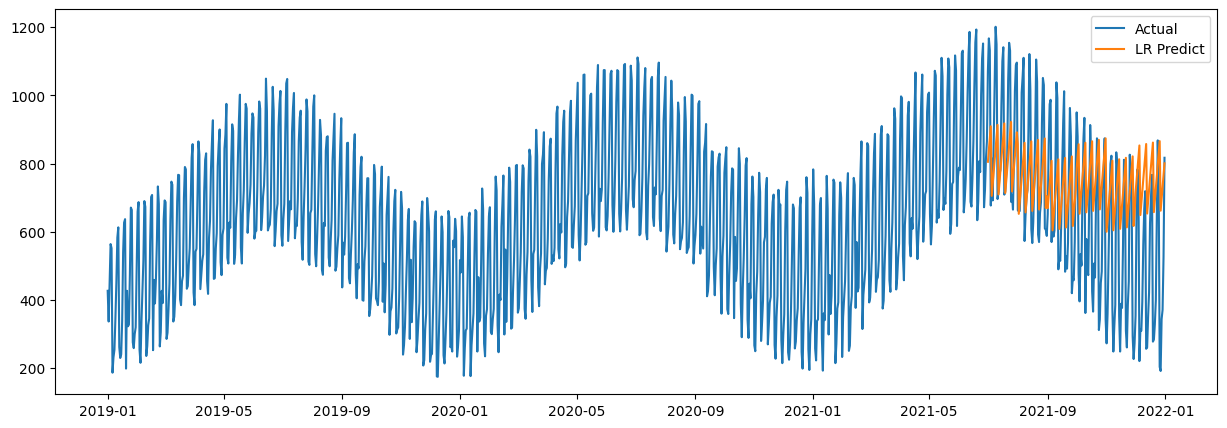

In [ ]:
plt.figure(figsize = (15,5))

plt.plot(time_series.item_count, label = "Actual")

plt.plot(test.lr_pred, label = "LR Predict")

plt.legend()

plt.show()

In [ ]:
lr_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.lr_pred)

lr_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.lr_pred)

lr_r2_score = r2_score(y_true = test.item_count, y_pred = test.lr_pred)

print("Linear Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(lr_rmse,lr_mae,lr_r2_score*100))

Linear Regression :
RMSE : 59638.94
MAE : 196.04
R2_Score : 7.65


In [ ]:

results = pd.DataFrame([lr_rmse, lr_mae,lr_r2_score*100], index = ['RMSE', 'MAE', 'R2_Score'], columns = ['Linear Regression']).round(2)

results

,Linear Regression
RMSE,59638.94
MAE,196.04
R2_Score,7.65


Random Forest

In [ ]:

rf = RandomForestRegressor(n_estimators=100, max_depth=20)

rf.fit(X_train, Y_train)

RandomForestRegressor(max_depth=20)

In [ ]:

test['rf_pred'] = rf.predict(X_test)

/tmp/ipython-input-2741068218.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rf_pred'] = rf.predict(X_test)


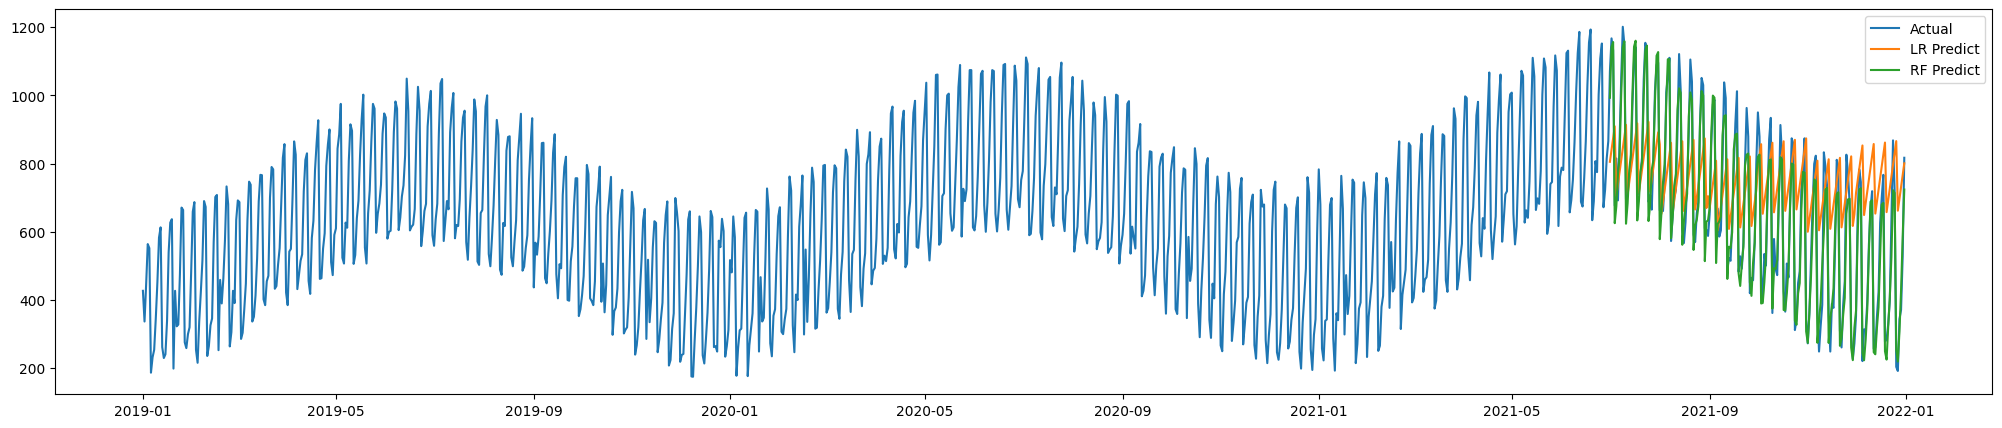

In [ ]:
plt.figure(figsize = (25,5))

plt.plot(time_series.item_count, label = "Actual")

plt.plot(test.lr_pred, label = "LR Predict")

plt.plot(test.rf_pred, label = "RF Predict")

plt.legend()

plt.show()

In [ ]:
rf_rmse = mean_squared_error(y_true = test.item_count, y_pred = test.rf_pred)

rf_mae = mean_absolute_error(y_true = test.item_count, y_pred = test.rf_pred)

rf_r2_score = r2_score(y_true = test.item_count, y_pred = test.rf_pred)

print("Random Forest Regression :\nRMSE : {:.2f}\nMAE : {:.2f}\nR2_Score : {:.2f}".format(rf_rmse,rf_mae,rf_r2_score*100))

Random Forest Regression :
RMSE : 3570.31
MAE : 47.38
R2_Score : 94.47


In [ ]:
results['Random Forest'] = [rf_rmse,rf_mae,rf_r2_score*100]

results.round(2)

,Linear Regression,Random Forest
RMSE,59638.94,3570.31
MAE,196.04,47.38
R2_Score,7.65,94.47


XGBoost

In [ ]:
 xgb = xgb.XGBRegressor(base_score=0.5, booster='gbtree',

                       n_estimators=1000,

                       early_stopping_rounds=50,

                       objective='reg:linear',

                       max_depth=3,

                       learning_rate=0.01)

xgb.fit(X_train, Y_train,

        eval_set=[(X_train, Y_train), (X_test, Y_test)],

        verbose=100)

[0]	validation_0-rmse:660.07829	validation_1-rmse:709.01212
[100]	validation_0-rmse:262.51190	validation_1-rmse:311.53220
[200]	validation_0-rmse:121.36888	validation_1-rmse:171.11193


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [10:13:00] WARNING: /workspace/src/objective/regression_obj.cu:282: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[300]	validation_0-rmse:71.72975	validation_1-rmse:105.03640
[400]	validation_0-rmse:52.50055	validation_1-rmse:78.37923
[500]	validation_0-rmse:44.19461	validation_1-rmse:71.59216
[591]	validation_0-rmse:40.35475	validation_1-rmse:72.11224


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

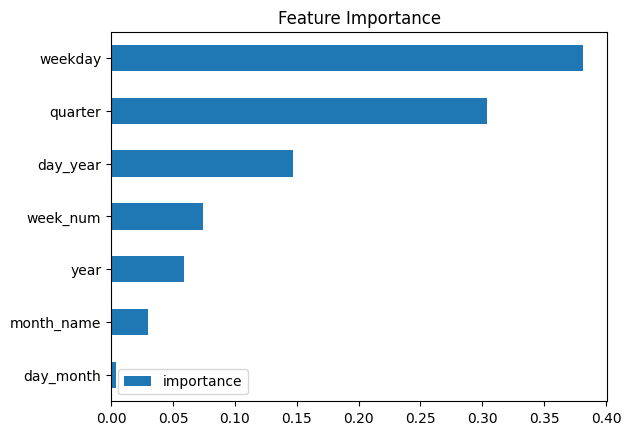

In [ ]:
importance = pd.DataFrame(data=xgb.feature_importances_,

             index=xgb.get_booster().feature_names,

             columns=['importance'])

importance.sort_values('importance').plot(kind='barh', title='Feature Importance')

plt.show()

In [ ]:
test['xgb_pred'] = xgb.predict(X_test)

/tmp/ipython-input-5488039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['xgb_pred'] = xgb.predict(X_test)


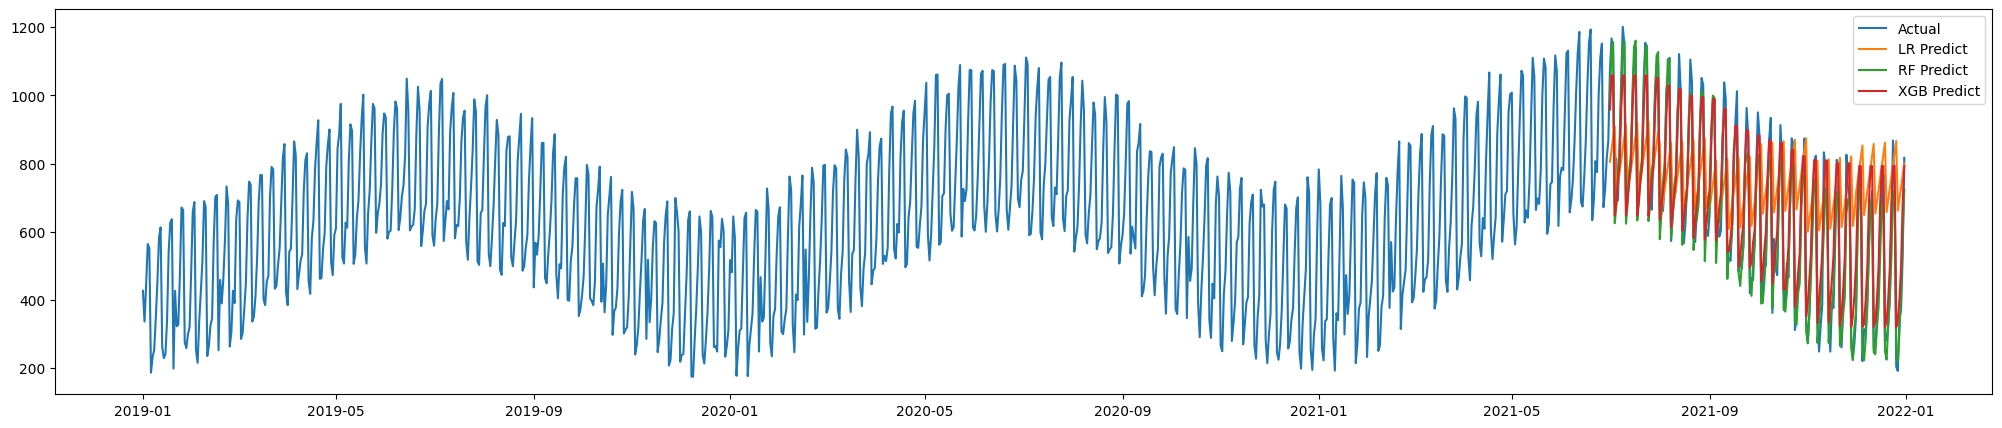

In [ ]:
plt.figure(figsize = (25,5))

plt.plot(time_series.item_count, label = "Actual")

plt.plot(test.lr_pred, label = "LR Predict")

plt.plot(test.rf_pred, label = "RF Predict")

plt.plot(test.xgb_pred, label = "XGB Predict")

plt.legend()

plt.show()

In [ ]:
xgb_model = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
xgb_model.fit(X_train, Y_train,
        eval_set=[(X_train, Y_train), (X_test, Y_test)],
        verbose=100)

AttributeError: 'XGBRegressor' object has no attribute 'XGBRegressor'